# Step 1 — Geographic Concentration & Market Dependency
**Objective:** Understand who Brazil's top trading partners are and how those relationships have evolved over 30 years.

This notebook follows a macro-to-micro structure:
1. Total trade value by year (exports vs imports)
2. Top trading partners nationally over time
3. Structural shifts — key moments and transitions
4. Share of trade by regional bloc over time

## Setup

This section initializes the database connection and defines the temporal scope of the analysis, restricting it to 2025 to avoid distortions from incomplete 2026 data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
from pathlib import Path
from sqlalchemy import create_engine
from dotenv import load_dotenv

# Credentials
dotenv_path = Path(r"C:\Users\e_koh\Downloads\State Analysis\brazil-state-trade-analysis\.env")
load_dotenv(dotenv_path, override=True)

DB_USER     = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST     = os.getenv("DB_HOST")
DB_PORT     = os.getenv("DB_PORT")
DB_NAME     = os.getenv("DB_NAME")

engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
print("Connected to database successfully")

## Data is capped at 2025 — 2026 contains only partial year data which distorts trend visuals
MAX_YEAR = 2025

Connected to database successfully


## 1.1 — Total Trade Value by Year (Exports vs Imports)
The broadest possible view: how has Brazil's total trade volume evolved since 1997?

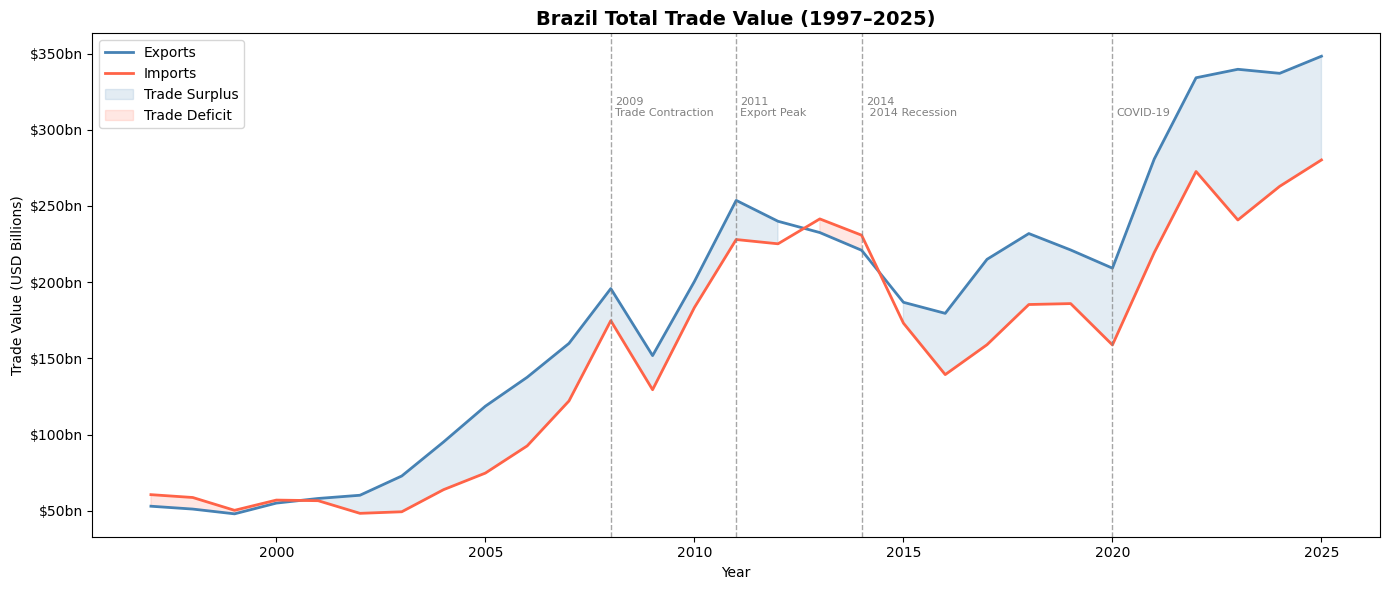

    year     total_fob  total_usd_bn
24  2021  2.808146e+11    280.814577
25  2022  3.341360e+11    334.136038
26  2023  3.396958e+11    339.695766
27  2024  3.370462e+11    337.046162
28  2025  3.482785e+11    348.278462


In [2]:
query_total = f"""
    SELECT "CO_ANO" AS year,
           SUM("VL_FOB") AS total_fob
    FROM exp
    WHERE "CO_ANO" <= {MAX_YEAR}
    GROUP BY "CO_ANO"
    ORDER BY "CO_ANO"
"""

query_total_imp = f"""
    SELECT "CO_ANO" AS year,
           SUM("VL_FOB") AS total_fob
    FROM imp
    WHERE "CO_ANO" <= {MAX_YEAR}
    GROUP BY "CO_ANO"
    ORDER BY "CO_ANO"
"""

df_exp_total = pd.read_sql(query_total, engine)
df_imp_total = pd.read_sql(query_total_imp, engine)

# Convert to USD billions
df_exp_total['total_usd_bn'] = df_exp_total['total_fob'] / 1e9
df_imp_total['total_usd_bn'] = df_imp_total['total_fob'] / 1e9

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_exp_total['year'], df_exp_total['total_usd_bn'], label='Exports', color='steelblue', linewidth=2)
ax.plot(df_imp_total['year'], df_imp_total['total_usd_bn'], label='Imports', color='tomato', linewidth=2)
ax.fill_between(df_exp_total['year'], df_exp_total['total_usd_bn'], df_imp_total['total_usd_bn'],
                where=df_exp_total['total_usd_bn'] >= df_imp_total['total_usd_bn'],
                alpha=0.15, color='steelblue', label='Trade Surplus')
ax.fill_between(df_exp_total['year'], df_exp_total['total_usd_bn'], df_imp_total['total_usd_bn'],
                where=df_exp_total['total_usd_bn'] < df_imp_total['total_usd_bn'],
                alpha=0.15, color='tomato', label='Trade Deficit')

# Annotate key events
## 2009 marker at mid-2008 to mark start of trade contraction
## 2011 marker at mid-2011 to mark the export peak
## COVID-19 marker at November 2019 to mark the onset of the disruption
events = {
    2009: ('2009\nTrade Contraction', 2008),
    2011: ('2011\nExport Peak',       2011),
    2014: ('2014\n 2014 Recession',   2014),
    2020: ('COVID-19',                2020)
}
for year, (label, xpos) in events.items():
    ax.axvline(x=xpos, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ax.text(xpos + 0.1, ax.get_ylim()[1] * 0.85, label, fontsize=8, color='gray')

ax.set_title(f"Brazil Total Trade Value (1997–{MAX_YEAR})", fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Trade Value (USD Billions)")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
plt.tight_layout()
plt.savefig('output_1_1_total_trade.png', dpi=150)
plt.show()
print(df_exp_total.tail())

### Overall Trade Growth

Brazil's total trade value grew from approximately **\\$55bn** in exports and **\\$60bn** in imports in 1997 to **\\$348bn** in exports and **\\$280bn** in imports by 2025 — a roughly **sixfold increase** on the export side over 28 years.

The growth was not linear and can be broken into six distinct periods:

| Period | What happened |
|---|---|
| 1997–2008 | Sustained growth in both exports and imports, with Brazil maintaining a consistent trade surplus |
| 2008–2009 Global Financial Crisis | Sharp contraction in both exports and imports, followed by a rapid recovery through to 2011 |
| 2011 Export Peak | Export values peaked in 2011 and began a multi-year decline. Brazil entered a trade deficit by approximately 2013 as imports continued to outpace falling exports |
| 2014 Recession | Brazil's domestic recession deepened the existing trade decline, with exports and imports reaching lows of ~\\$185bn and ~\\$140bn respectively by 2016 |
| 2017–2020 | Partial recovery in both exports and imports, restoring a trade surplus. Contrary to what might be expected, Brazil's goods trade did not contract during the COVID-19 period — exports and imports held steady or continued upward from 2020. The drivers of this resilience require further investigation |
| 2021–2025 | The strongest sustained growth period in the dataset, with exports reaching ~\\$348bn and imports ~\\$280bn by 2025 — and the trade surplus widening to approximately \\$70bn |

> ⚠️ *Requires further investigation: Why did Brazil's goods trade not contract during COVID-19 (2020)? Possible factors include sustained Chinese commodity demand, agricultural export resilience, and BRL depreciation inflating USD-denominated values — but these require product-level and macroeconomic data to confirm.*


## 1.2 — Top 10 Export Partners by Year
Which countries have received the most Brazilian exports, and how has that ranking evolved?

Summary of the current state — who are Brazil's top 10 export and import partners today?

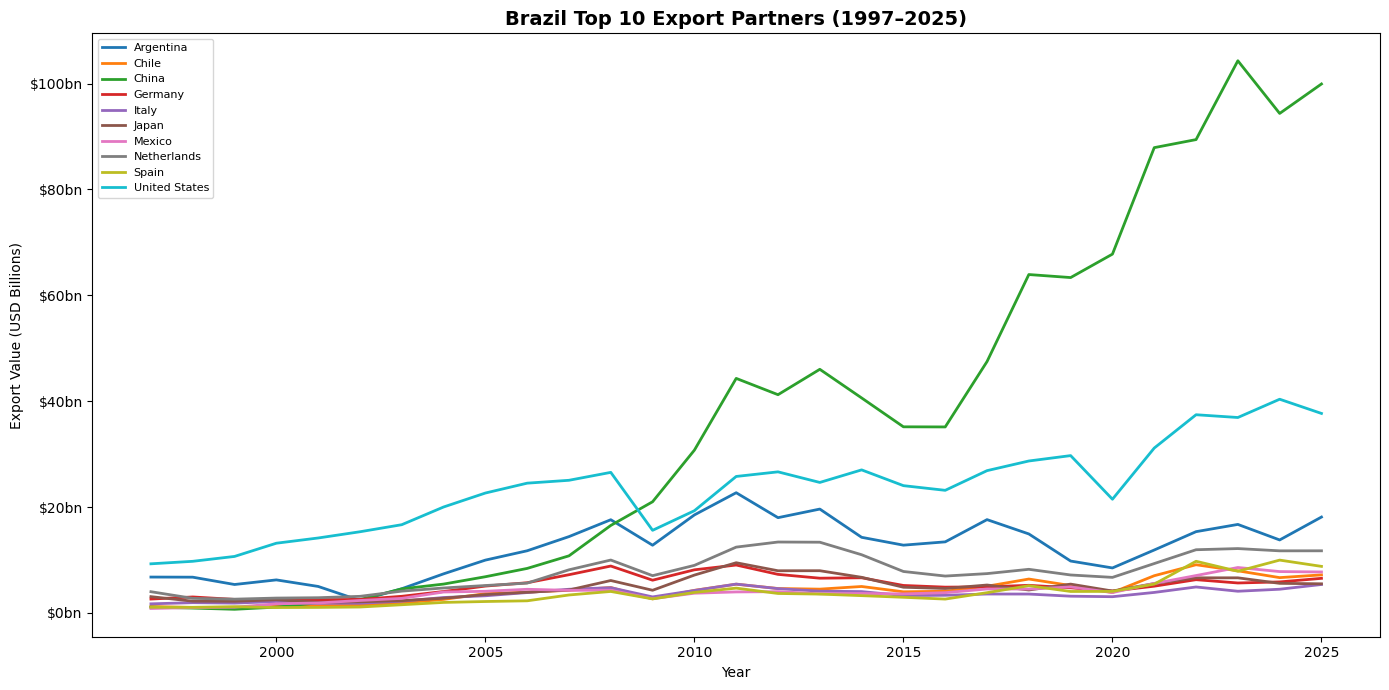

Top 10 Export Partners (2025) — Total Exports: USD 348.3bn
      country  exports_usd_bn  share_%
        China           99.94    28.70
United States           37.68    10.82
    Argentina           18.11     5.20
  Netherlands           11.73     3.37
        Spain            8.78     2.52
       Mexico            7.73     2.22
    Singapore            7.35     2.11
       Canada            7.25     2.08
        Chile            7.18     2.06
        India            6.87     1.97

Top 10 Import Partners (2025) — Total Imports: USD 280.2bn
      country  imports_usd_bn  share_%
        China           70.92    25.31
United States           45.14    16.11
      Germany           14.40     5.14
    Argentina           12.93     4.62
       Russia            9.41     3.36
        India            8.34     2.98
       France            7.20     2.57
        Italy            7.05     2.52
       Mexico            6.21     2.22
        Japan            6.05     2.16


In [9]:
query_top_partners = f"""
    SELECT e."CO_ANO" AS year,
           p.nome_pais_ing AS country,
           SUM(e."VL_FOB") AS total_fob
    FROM exp e
    JOIN pais p ON e."CO_PAIS" = p.codigo_pais
    WHERE e."CO_ANO" <= {MAX_YEAR}
    GROUP BY e."CO_ANO", p.nome_pais_ing
    ORDER BY e."CO_ANO", total_fob DESC
"""

df_partners = pd.read_sql(query_top_partners, engine)
df_partners['total_usd_bn'] = df_partners['total_fob'] / 1e9

# Get top 10 countries by total exports across all years
top10_countries = (
    df_partners.groupby('country')['total_fob']
    .sum()
    .nlargest(10)
    .index.tolist()
)

df_top10 = df_partners[df_partners['country'].isin(top10_countries)]

# Pivot for plotting
df_pivot = df_top10.pivot(index='year', columns='country', values='total_usd_bn').fillna(0)

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
for country in df_pivot.columns:
    ax.plot(df_pivot.index, df_pivot[country], label=country, linewidth=2)

ax.set_title(f"Brazil Top 10 Export Partners (1997–{MAX_YEAR})", fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Export Value (USD Billions)")
ax.legend(loc='upper left', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
plt.tight_layout()
plt.savefig('output_1_2_top10_export_partners.png', dpi=150)
plt.show()

## 2026 data excluded — only partial year available, which distorts the summary figures
## Using MAX_YEAR = 2025 as the reference year for the summary table

# Query total exports and imports for MAX_YEAR (all countries)
query_total_exp_year = f"SELECT SUM(\"VL_FOB\") AS total FROM exp WHERE \"CO_ANO\" = {MAX_YEAR}"
query_total_imp_year = f"SELECT SUM(\"VL_FOB\") AS total FROM imp WHERE \"CO_ANO\" = {MAX_YEAR}"
total_exp = pd.read_sql(query_total_exp_year, engine)['total'].iloc[0]
total_imp = pd.read_sql(query_total_imp_year, engine)['total'].iloc[0]

query_latest_exp = f"""
    SELECT p.nome_pais_ing AS country,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN pais p ON e."CO_PAIS" = p.codigo_pais
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY p.nome_pais_ing
    ORDER BY exports_usd DESC
    LIMIT 10
"""

query_latest_imp = f"""
    SELECT p.nome_pais_ing AS country,
           SUM(i."VL_FOB") AS imports_usd
    FROM imp i
    JOIN pais p ON i."CO_PAIS" = p.codigo_pais
    WHERE i."CO_ANO" = {MAX_YEAR}
    GROUP BY p.nome_pais_ing
    ORDER BY imports_usd DESC
    LIMIT 10
"""

df_latest_exp = pd.read_sql(query_latest_exp, engine)
df_latest_imp = pd.read_sql(query_latest_imp, engine)

df_latest_exp['exports_usd_bn'] = (df_latest_exp['exports_usd'] / 1e9).round(2)
df_latest_exp['share_%'] = (df_latest_exp['exports_usd'] / total_exp * 100).round(2)

df_latest_imp['imports_usd_bn'] = (df_latest_imp['imports_usd'] / 1e9).round(2)
df_latest_imp['share_%'] = (df_latest_imp['imports_usd'] / total_imp * 100).round(2)

print(f"Top 10 Export Partners ({MAX_YEAR}) — Total Exports: USD {total_exp/1e9:.1f}bn")
print(df_latest_exp[['country', 'exports_usd_bn', 'share_%']].to_string(index=False))
print(f"\nTop 10 Import Partners ({MAX_YEAR}) — Total Imports: USD {total_imp/1e9:.1f}bn")
print(df_latest_imp[['country', 'imports_usd_bn', 'share_%']].to_string(index=False))


### The China Shift

The single most significant structural change in Brazilian trade over the last 30 years is the rise of China as Brazil's dominant export destination.

> **China overtook the United States as Brazil's largest export partner in 2009** — the same year the global financial crisis compressed demand from Western markets — and has not relinquished that position since.

| Partner | 1997 Share | 2025 Value | 2025 Share |
|---|---|---|---|
| China | ~negligible | \\$99.9bn | 28.7% |
| United States | largest partner | \\$37.7bn | 10.8% |

The gap has widened dramatically since 2016, with China's export value more than doubling from approximately **\\$35bn to just under \\$100bn**. No other trading partner comes close — the United States received less than half of China's share in 2025.

## 1.3 — China vs USA: The Structural Shift
One of the most significant structural changes in Brazilian trade over the last 30 years is China overtaking the United States as Brazil's largest trading partner. This cell isolates that story.

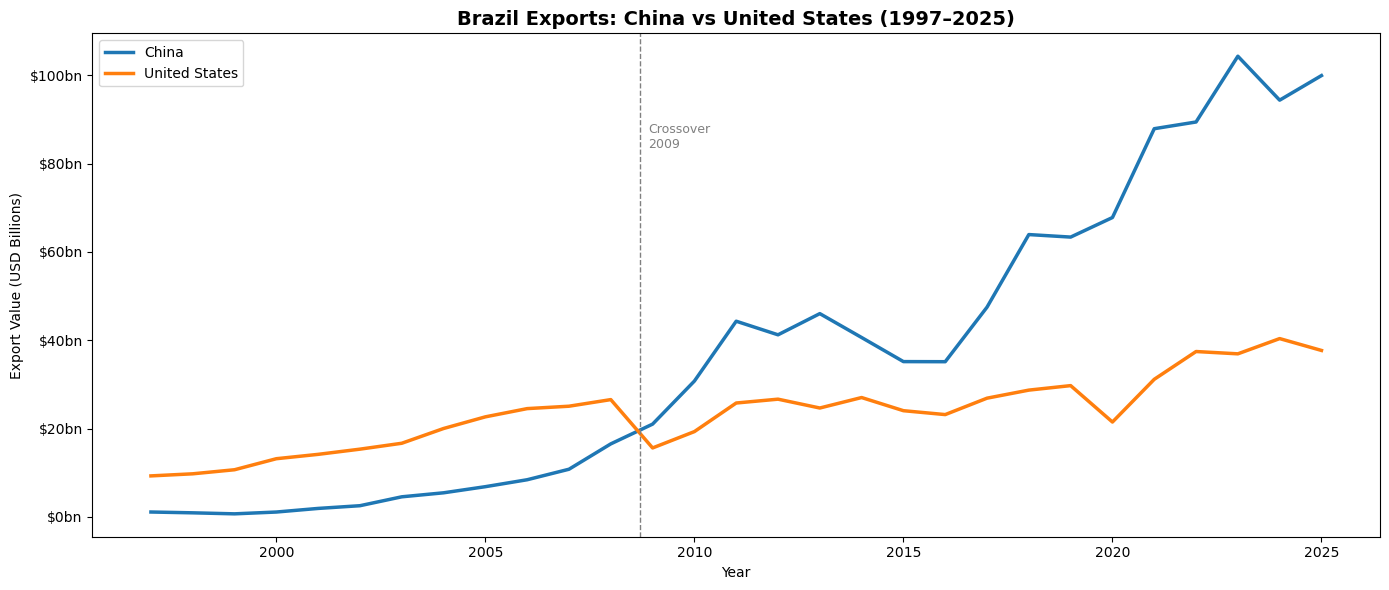

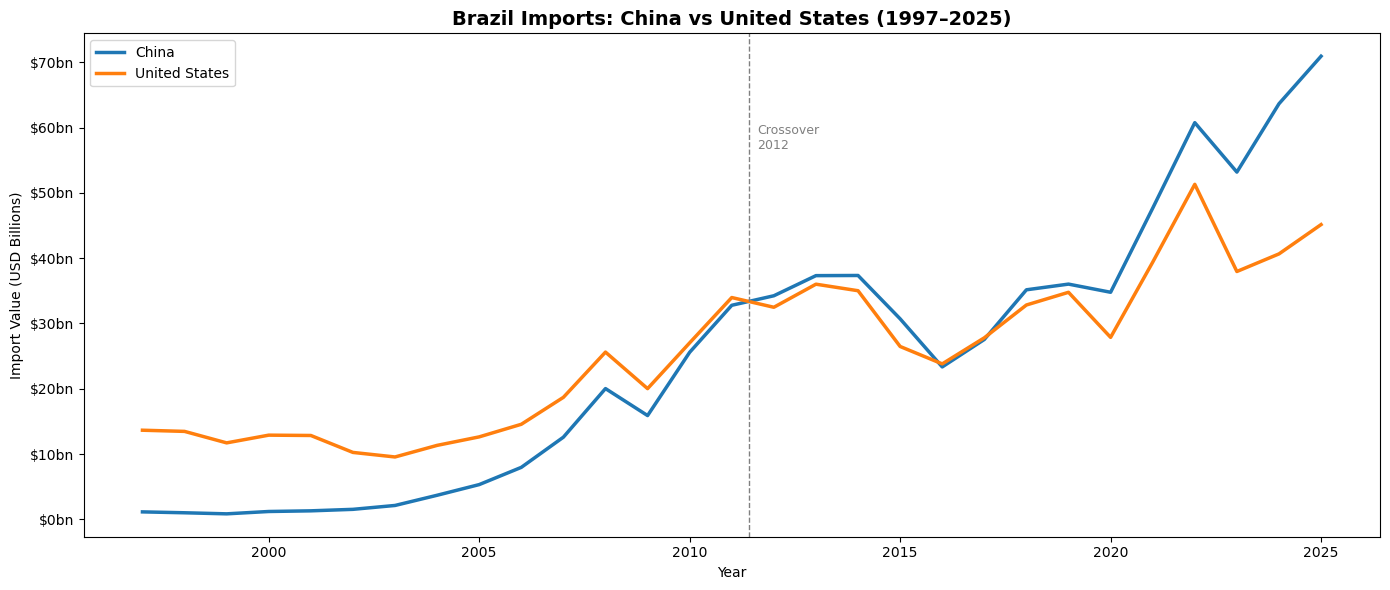

In [4]:
query_china_usa = f"""
    SELECT e."CO_ANO" AS year,
           p.nome_pais_ing AS country,
           SUM(e."VL_FOB") AS total_fob
    FROM exp e
    JOIN pais p ON e."CO_PAIS" = p.codigo_pais
    WHERE p.nome_pais_ing IN ('China', 'United States')
    AND e."CO_ANO" <= {MAX_YEAR}
    GROUP BY e."CO_ANO", p.nome_pais_ing
    ORDER BY e."CO_ANO"
"""

df_china_usa = pd.read_sql(query_china_usa, engine)
df_china_usa['total_usd_bn'] = df_china_usa['total_fob'] / 1e9
df_pivot_cu = df_china_usa.pivot(index='year', columns='country', values='total_usd_bn').fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
for country in df_pivot_cu.columns:
    ax.plot(df_pivot_cu.index, df_pivot_cu[country], label=country, linewidth=2.5)

# Find and annotate the crossover year
cols = df_pivot_cu.columns.tolist()
if len(cols) == 2:
    crossover = df_pivot_cu[df_pivot_cu[cols[0]] > df_pivot_cu[cols[1]]].index
    if len(crossover) > 0:
        xpos = crossover[0] - 0.3
        ax.axvline(x=xpos, color='gray', linestyle='--', linewidth=1)
        ax.text(xpos + 0.2, df_pivot_cu.max().max() * 0.8,
                f'Crossover\n{crossover[0]}', fontsize=9, color='gray')

ax.set_title(f"Brazil Exports: China vs United States (1997–{MAX_YEAR})", fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Export Value (USD Billions)")
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
plt.tight_layout()
plt.savefig('output_1_3_china_vs_usa.png', dpi=150)
plt.show()

query_china_usa_imp = f"""
    SELECT i."CO_ANO" AS year,
           p.nome_pais_ing AS country,
           SUM(i."VL_FOB") AS total_fob
    FROM imp i
    JOIN pais p ON i."CO_PAIS" = p.codigo_pais
    WHERE p.nome_pais_ing IN ('China', 'United States')
    AND i."CO_ANO" <= {MAX_YEAR}
    GROUP BY i."CO_ANO", p.nome_pais_ing
    ORDER BY i."CO_ANO"
"""

df_china_usa_imp = pd.read_sql(query_china_usa_imp, engine)
df_china_usa_imp['total_usd_bn'] = df_china_usa_imp['total_fob'] / 1e9
df_pivot_cu_imp = df_china_usa_imp.pivot(index='year', columns='country', values='total_usd_bn').fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
for country in df_pivot_cu_imp.columns:
    ax.plot(df_pivot_cu_imp.index, df_pivot_cu_imp[country], label=country, linewidth=2.5)

# Find and annotate the crossover year
cols = df_pivot_cu_imp.columns.tolist()
if len(cols) == 2:
    crossover = df_pivot_cu_imp[df_pivot_cu_imp[cols[0]] > df_pivot_cu_imp[cols[1]]].index
    if len(crossover) > 0:
        xpos = crossover[0] - 0.6
        ax.axvline(x=xpos, color='gray', linestyle='--', linewidth=1)
        ax.text(xpos + 0.2, df_pivot_cu_imp.max().max() * 0.8,
                f'Crossover\n{crossover[0]}', fontsize=9, color='gray')

ax.set_title(f"Brazil Imports: China vs United States (1997–{MAX_YEAR})", fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Import Value (USD Billions)")
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
plt.tight_layout()
plt.savefig('output_1_3b_china_vs_usa_imports.png', dpi=150)
plt.show()

### USA and China

Brazil's relationships with its two largest trading partners are **structurally opposite** in nature:

| Relationship | Nature | Balance |
|---|---|---|
| Brazil → China | China is Brazil's largest **customer** | **+\\$29.0bn surplus** |
| Brazil → United States | US functions primarily as a **supplier** | **-\\$7.5bn deficit** |

This asymmetry is analytically significant: Brazil's export revenues are disproportionately dependent on Chinese demand, while its import supply chains are more exposed to US pricing and availability.

## 1.4 — Share of Trade by Regional Bloc Over Time
How has the distribution of Brazilian trade across regional blocs (Mercosul, EU, Asia, etc.) shifted over 30 years?

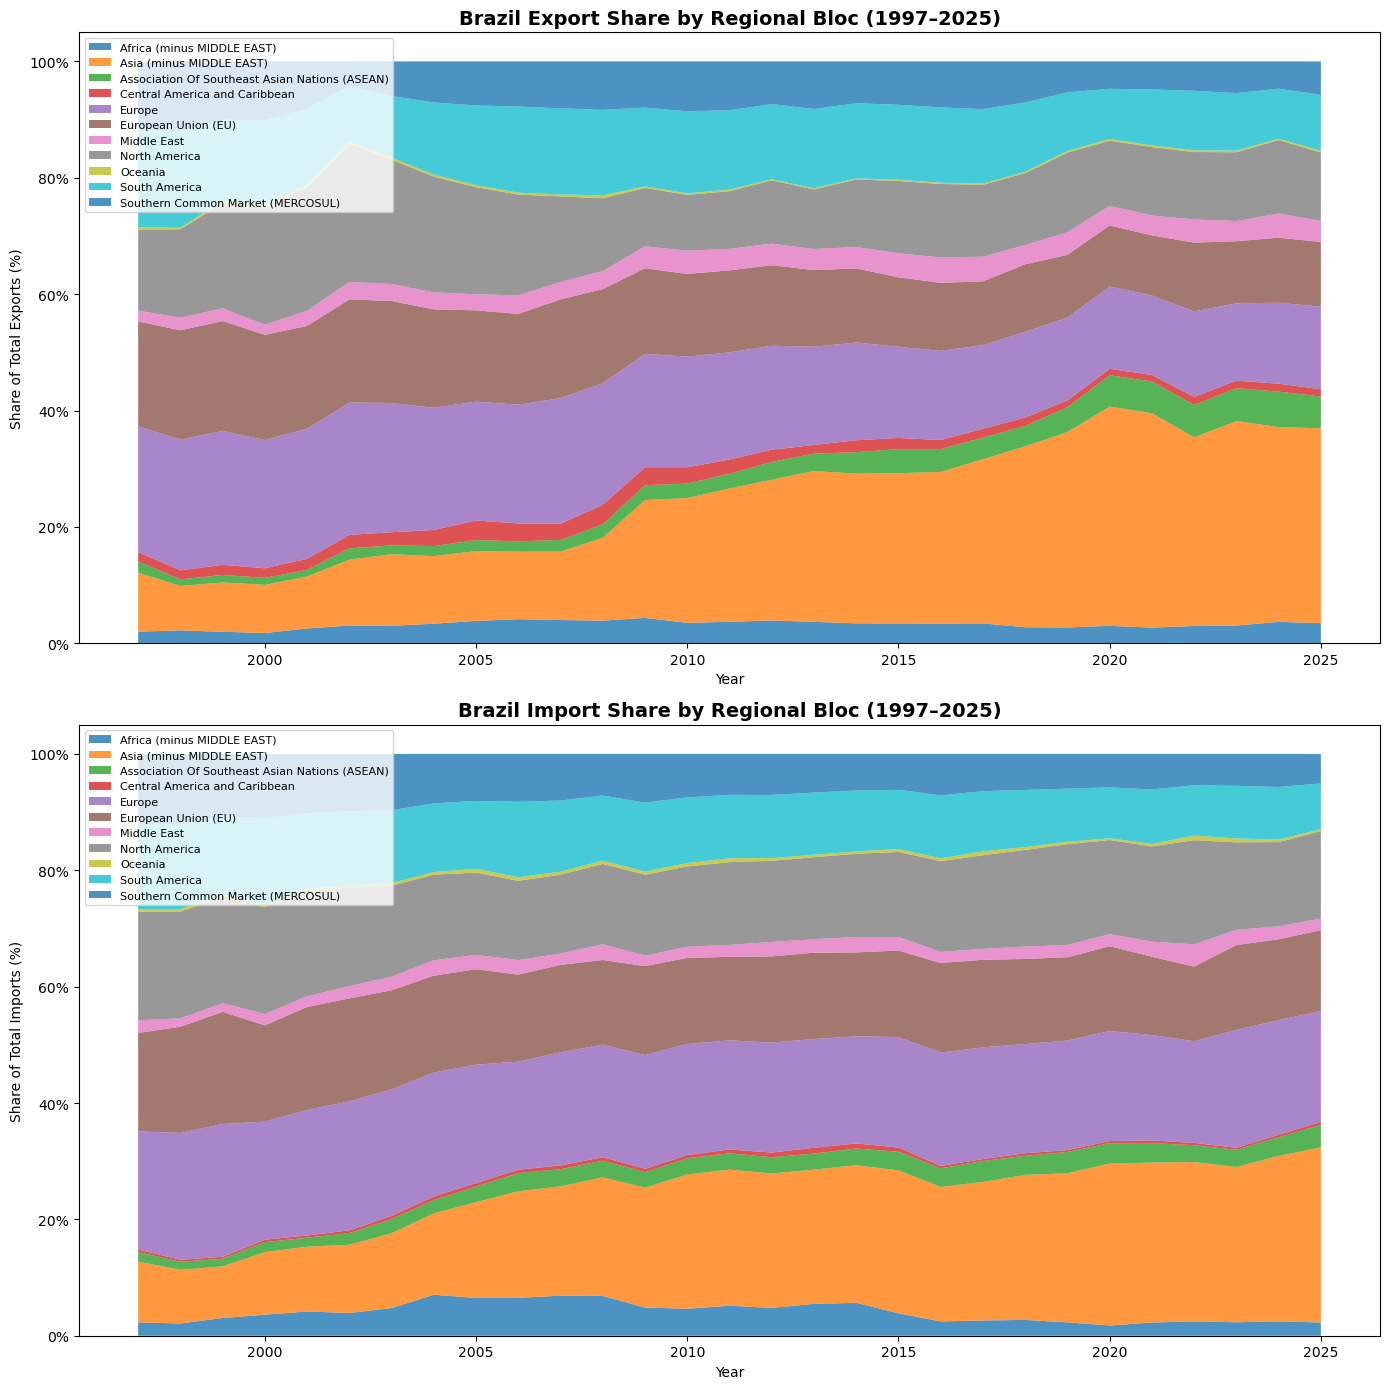

In [11]:
query_blocs = f"""
    SELECT e."CO_ANO" AS year,
           pb.nome_bloco_ing AS bloc,
           SUM(e."VL_FOB") AS total_fob
    FROM exp e
    JOIN pais_bloco pb ON e."CO_PAIS" = pb.codigo_pais
    WHERE e."CO_ANO" <= {MAX_YEAR}
    GROUP BY e."CO_ANO", pb.nome_bloco_ing
    ORDER BY e."CO_ANO", total_fob DESC
"""

query_blocs_imp = f"""
    SELECT i."CO_ANO" AS year,
           pb.nome_bloco_ing AS bloc,
           SUM(i."VL_FOB") AS total_fob
    FROM imp i
    JOIN pais_bloco pb ON i."CO_PAIS" = pb.codigo_pais
    WHERE i."CO_ANO" <= {MAX_YEAR}
    GROUP BY i."CO_ANO", pb.nome_bloco_ing
    ORDER BY i."CO_ANO", total_fob DESC
"""

df_blocs     = pd.read_sql(query_blocs, engine)
df_blocs_imp = pd.read_sql(query_blocs_imp, engine)

def build_bloc_pct(df, n=11):
    df['total_usd_bn'] = df['total_fob'] / 1e9
    top_blocs = (
        df.groupby('bloc')['total_fob']
        .sum()
        .nlargest(n)
        .index.tolist()
    )
    df_top    = df[df['bloc'].isin(top_blocs)]
    df_pivot  = df_top.pivot(index='year', columns='bloc', values='total_usd_bn').fillna(0)
    df_pct    = df_pivot.div(df_pivot.sum(axis=1), axis=0) * 100
    return df_pct

df_exp_pct = build_bloc_pct(df_blocs)
df_imp_pct = build_bloc_pct(df_blocs_imp)

def add_pct_annotations(ax, df_pct, start_year, end_year):
    ## Annotate the share of each bloc in start_year and end_year on the right side
    for bloc in df_pct.columns:
        start_val = df_pct.loc[start_year, bloc] if start_year in df_pct.index else 0
        end_val   = df_pct.loc[end_year,   bloc] if end_year   in df_pct.index else 0
        if end_val > 1:  ## Only annotate blocs with meaningful share
            ax.annotate(
                f"{bloc}: {start_val:.1f}% → {end_val:.1f}%",
                xy=(end_year, df_pct.loc[:end_year, bloc].cumsum().iloc[-1] - end_val / 2),
                xytext=(end_year + 0.3, df_pct.loc[:end_year, bloc].cumsum().iloc[-1] - end_val / 2),
                fontsize=7, va='center'
            )

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 14))

## ---- EXPORTS ----
ax1.stackplot(df_exp_pct.index, df_exp_pct.T, labels=df_exp_pct.columns, alpha=0.8)
ax1.set_title(f"Brazil Export Share by Regional Bloc (1997–{MAX_YEAR})", fontsize=14, fontweight='bold')
ax1.set_xlabel("Year")
ax1.set_ylabel("Share of Total Exports (%)")
ax1.legend(loc='upper left', fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

## Add 1997 and MAX_YEAR percentage summary below the export chart
start_year, end_year = df_exp_pct.index[0], df_exp_pct.index[-1]
summary_exp = pd.DataFrame({
    'Bloc'            : df_exp_pct.columns,
    f'{start_year} (%)': df_exp_pct.loc[start_year].round(1).values,
    f'{end_year} (%)' : df_exp_pct.loc[end_year].round(1).values,
    'Change (pp)'     : (df_exp_pct.loc[end_year] - df_exp_pct.loc[start_year]).round(1).values
})

## ---- IMPORTS ----
ax2.stackplot(df_imp_pct.index, df_imp_pct.T, labels=df_imp_pct.columns, alpha=0.8)
ax2.set_title(f"Brazil Import Share by Regional Bloc (1997–{MAX_YEAR})", fontsize=14, fontweight='bold')
ax2.set_xlabel("Year")
ax2.set_ylabel("Share of Total Imports (%)")
ax2.legend(loc='upper left', fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

## Add 1997 and MAX_YEAR percentage summary below the import chart
summary_imp = pd.DataFrame({
    'Bloc'            : df_imp_pct.columns,
    f'{start_year} (%)': df_imp_pct.loc[start_year].round(1).values,
    f'{end_year} (%)' : df_imp_pct.loc[end_year].round(1).values,
    'Change (pp)'     : (df_imp_pct.loc[end_year] - df_imp_pct.loc[start_year]).round(1).values
})

plt.tight_layout()
plt.savefig('output_1_4_bloc_share.png', dpi=150)
plt.show()

## Summary tables showing share in first and last year and the change in percentage points --> manually added in markdown
##print(f"Export bloc share — {start_year} vs {end_year}")
##print(summary_exp.sort_values(f'{end_year} (%)', ascending=False).to_string(index=False))
##print(f"\nImport bloc share — {start_year} vs {end_year}")
##print(summary_imp.sort_values(f'{end_year} (%)', ascending=False).to_string(index=False))

### Regional Bloc Shifts

At the bloc level, the dominant story is the **rise of Asia and the relative decline of every other major bloc**. Africa, the Middle East and ASEAN show modest gains on the export side, while all other blocs lost share.

#### Export Share and Volume by Bloc

*Total exports: ~\\$55bn (1997) → \\$348bn (2025)*

| Bloc | 1997 (%) | 1997 (~\\$bn) | 2025 (%) | 2025 (~\\$bn) | Change (pp) |
|---|---|---|---|---|---|
| Asia (ex. Middle East) | 10.1% | ~\\$5.6bn | 33.5% | ~\\$116.6bn | **+23.4** |
| Europe | 21.6% | ~\\$11.9bn | 14.2% | ~\\$49.4bn | -7.4 |
| South America | 16.7% | ~\\$9.2bn | 9.7% | ~\\$33.8bn | -7.1 |
| European Union (EU) | 18.0% | ~\\$9.9bn | 11.1% | ~\\$38.6bn | -6.9 |
| MERCOSUL | 11.8% | ~\\$6.5bn | 5.7% | ~\\$19.8bn | -6.1 |
| North America | 13.9% | ~\\$7.7bn | 11.8% | ~\\$41.1bn | -2.2 |
| ASEAN | 2.0% | ~\\$1.1bn | 5.4% | ~\\$18.8bn | **+3.5** |
| Middle East | 1.9% | ~\\$1.0bn | 3.6% | ~\\$12.5bn | +1.7 |
| Africa (ex. Middle East) | 2.0% | ~\\$1.1bn | 3.5% | ~\\$12.2bn | +1.5 |
| Central America & Caribbean | 1.6% | ~\\$0.9bn | 1.3% | ~\\$4.5bn | -0.3 |
| Oceania | 0.4% | ~\\$0.2bn | 0.3% | ~\\$1.0bn | -0.1 |

#### Import Share and Volume by Bloc

*Total imports: ~\\$60bn (1997) → \\$280bn (2025)*

| Bloc | 1997 (%) | 1997 (~\\$bn) | 2025 (%) | 2025 (~\\$bn) | Change (pp) |
|---|---|---|---|---|---|
| Asia (ex. Middle East) | 10.4% | ~\\$6.2bn | 30.1% | ~\\$84.3bn | **+19.7** |
| Europe | 20.3% | ~\\$12.2bn | 19.1% | ~\\$53.5bn | -1.2 |
| North America | 18.6% | ~\\$11.2bn | 15.0% | ~\\$42.0bn | -3.6 |
| European Union (EU) | 16.9% | ~\\$10.1bn | 13.9% | ~\\$38.9bn | -3.0 |
| South America | 14.8% | ~\\$8.9bn | 7.9% | ~\\$22.1bn | -6.9 |
| MERCOSUL | 12.0% | ~\\$7.2bn | 5.1% | ~\\$14.3bn | **-6.9** |
| ASEAN | 1.7% | ~\\$1.0bn | 3.9% | ~\\$10.9bn | +2.2 |
| Africa (ex. Middle East) | 2.3% | ~\\$1.4bn | 2.3% | ~\\$6.4bn | 0.0 |
| Middle East | 2.2% | ~\\$1.3bn | 2.0% | ~\\$5.6bn | -0.2 |
| Central America & Caribbean | 0.4% | ~\\$0.2bn | 0.5% | ~\\$1.4bn | +0.1 |
| Oceania | 0.4% | ~\\$0.2bn | 0.3% | ~\\$0.8bn | -0.1 |

*Note: Volume figures are approximated from total trade values and bloc percentage shares. 1997 figures use ~\\$55bn exports and ~\\$60bn imports as base.*

Three structural shifts stand out beyond the headline Asia story:

**ASEAN** has nearly tripled its share of Brazilian exports (2.0% → 5.4%, +3.5pp) and grown significantly on the import side (+2.2pp), signalling the rise of Southeast Asia as a distinct trade relationship separate from China.

**Africa and the Middle East** each grew modestly on the export side (+1.5pp and +1.7pp respectively), suggesting these are emerging rather than established markets for Brazilian exports. On the import side both blocs held roughly flat.

The most notable import-side finding remains the **stability of Europe** as a supplier (20.3% → 19.1%, -1.2pp) contrasting with its sharper decline as a buyer on the export side (-7.4pp). In absolute terms, European imports into Brazil grew from ~\\$12.2bn to ~\\$53.5bn — the share held steady because European import growth kept pace with Brazil's overall import expansion. The nature of what drives this stability requires further investigation at the product level.

> ⚠️ *Requires further investigation (Step 5): What specific product categories does Brazil import from Europe, and has the composition of those imports changed over time?*

The sharp decline of **MERCOSUL** on both sides (-6.1pp exports, -6.9pp imports) raises questions about the practical effectiveness of regional trade integration — in absolute terms, MERCOSUL imports grew from ~\\$7.2bn to ~\\$14.3bn, meaning growth was significantly slower than the overall expansion of Brazilian trade. The bloc's share has more than halved since 1997 despite its formal existence.

> ⚠️ *Requires further investigation (Step 7): Did specific trade agreements or policy changes contribute to the decline of intra-MERCOSUL trade share?*


## 1.5 — Trade Balance by Country (Largest Surpluses & Deficits)
Which countries does Brazil run its largest trade surpluses and deficits with? A positive balance means Brazil exports more than it imports from that country. A negative balance means the opposite.

In [7]:
## Trade balance = exports - imports per country for MAX_YEAR
## Positive = surplus (Brazil exports more to that country than it imports)
## Negative = deficit (Brazil imports more from that country than it exports)
## Using subqueries to pre-filter by year to avoid PostgreSQL type conflict in JOIN conditions

query_balance = f"""
    SELECT p.nome_pais_ing AS country,
           COALESCE(e.exports_usd, 0) AS exports_usd,
           COALESCE(i.imports_usd, 0) AS imports_usd,
           COALESCE(e.exports_usd, 0) - COALESCE(i.imports_usd, 0) AS balance_usd
    FROM pais p
    LEFT JOIN (
        SELECT "CO_PAIS", SUM("VL_FOB") AS exports_usd
        FROM exp
        WHERE "CO_ANO" = {MAX_YEAR}
        GROUP BY "CO_PAIS"
    ) e ON e."CO_PAIS" = p.codigo_pais
    LEFT JOIN (
        SELECT "CO_PAIS", SUM("VL_FOB") AS imports_usd
        FROM imp
        WHERE "CO_ANO" = {MAX_YEAR}
        GROUP BY "CO_PAIS"
    ) i ON i."CO_PAIS" = p.codigo_pais
    WHERE COALESCE(e.exports_usd, 0) > 0 OR COALESCE(i.imports_usd, 0) > 0
    ORDER BY balance_usd DESC
"""

df_balance = pd.read_sql(query_balance, engine)
df_balance['exports_usd_bn'] = (df_balance['exports_usd'] / 1e9).round(2)
df_balance['imports_usd_bn'] = (df_balance['imports_usd'] / 1e9).round(2)
df_balance['balance_usd_bn'] = (df_balance['balance_usd'] / 1e9).round(2)

## Top 10 surpluses — countries where Brazil exports most relative to imports
df_surplus = df_balance.head(10)[['country', 'exports_usd_bn', 'imports_usd_bn', 'balance_usd_bn']]

## Top 10 deficits — countries where Brazil imports most relative to exports
df_deficit = df_balance.tail(10).sort_values('balance_usd_bn')[['country', 'exports_usd_bn', 'imports_usd_bn', 'balance_usd_bn']]

print(f"10 Largest Trade Surpluses ({MAX_YEAR}) — countries Brazil exports most to relative to imports")
print(df_surplus.to_string(index=False))
print(f"\n10 Largest Trade Deficits ({MAX_YEAR}) — countries Brazil imports most from relative to exports")
print(df_deficit.to_string(index=False))

10 Largest Trade Surpluses (2025) — countries Brazil exports most to relative to imports
             country  exports_usd_bn  imports_usd_bn  balance_usd_bn
               China           99.94           70.92           29.02
         Netherlands           11.73            2.37            9.36
           Argentina           18.11           12.93            5.17
               Spain            8.78            3.82            4.96
              Canada            7.25            3.14            4.11
           Singapore            7.35            3.30            4.05
United Arab Emirates            3.76            0.63            3.14
                Iran            2.92            0.08            2.84
              Turkey            4.15            1.42            2.73
               Chile            7.18            4.63            2.55

10 Largest Trade Deficits (2025) — countries Brazil imports most from relative to exports
      country  exports_usd_bn  imports_usd_bn  balance_usd_bn

### The Surplus/Deficit Asymmetry

**Countries with Brazil's largest trade deficits (2025):**

| Country | Exports | Imports | Balance |
|---|---|---|---|
| Russia | \\$1.5bn | \\$9.4bn | -\\$7.9bn |
| Germany | \\$6.5bn | \\$14.4bn | -\\$7.9bn |
| United States | \\$37.7bn | \\$45.1bn | -\\$7.5bn |
| France | \\$3.1bn | \\$7.2bn | -\\$4.1bn |

Brazil runs its largest deficits with a small number of large economies. Whether these deficits are driven by specific product categories is not determinable from country-level data alone.

> ⚠️ *Requires further investigation (Step 5): What product categories account for Brazil's largest trade deficits? Has the composition of these deficits shifted over time?*


# Key Findings — Step 1: Geographic Concentration & Market Dependency

## Business Implications

Three implications stand out for companies planning market entry into Brazil or building supply chains that run through it:

**1. Concentration Risk**
A single buyer (China) accounts for more than a quarter of all export revenue. Any slowdown in Chinese demand — whether driven by economic cycle, geopolitical tension or commodity price shifts — has outsized consequences for Brazilian exporters and the sectors that supply them.

**2. Structural Role in Global Trade**
The surplus with China and deficit with the US and Europe reflects an asymmetry in Brazil's trade relationships that has deepened over 30 years. What drives this structural pattern at the product level remains to be examined in Step 5, but the country-level concentration itself has direct implications for risk assessment in market entry and supply chain strategy.

> ⚠️ *Requires further investigation (Step 5): What product categories underpin Brazil's surplus with China and its deficits with Western economies?*

**3. Widening Trade Surplus**
Brazil's overall trade surplus has widened significantly since 2020, reaching approximately \\$70bn in 2025. What macroeconomic consequences this carries — for currency, purchasing power or domestic demand — is beyond the scope of this trade flow analysis and would require additional economic data to assess.

---

## Limitations

- **Goods trade only** — this analysis excludes services, which account for a meaningful share of Brazil's economic relationships, particularly with the United States (tourism, financial services, technology)
- **National aggregation masks state-level variation** — São Paulo's trade profile is structurally different from Pará or Mato Grosso, and the China dependency may be heavily concentrated in a small number of commodity-producing states
- **Bloc classification overlaps** — some countries appear in multiple blocs (e.g. EU countries also appear in Europe), which affects percentage totals in the bloc analysis
- **COVID-19 trade resilience unexplained** — Brazil's goods trade did not contract during 2020 as might be expected; the drivers of this resilience are not determinable from trade flow data alone

These dimensions will be addressed directly in **Steps 2 and 5**.

---

## What Comes Next

**Step 2** will disaggregate these national findings to the state level — examining which of Brazil's 26 states drive exports, which sectors dominate each region, and whether the China dependency identified here is uniformly distributed or concentrated in specific geographic and commodity hubs.
